# 01 · Data exploration

The later models need to know what kind of shot each stroke was.The csv does not say, so we have to work it out from three things: the lie, the distance, and the par. The lies are anonymised and par is missing, so this notebook recovers them and checks the data quality.

Order of work: rebuild each hole, decode the lies, cross-check the numbers, flag bad data, infer par, then label every shot.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.data_prep import (
    load_raw, add_basic_features, flag_quality, infer_par, add_par_and_category,
    LIE_MAP, LIE_LABEL, LIE_GROUP, HOLE_KEY, ROUND_KEY, COURSE_HOLE_KEY,
)
from src.viz import set_style, PALETTE, NEUTRAL, INK_2

set_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

DATA = "../data/shot_data.csv"

## Step 1 · Look at the columns

In [2]:
raw = load_raw(DATA)
print(f"{len(raw):,} rows · {raw.player_id.nunique()} players · {raw.event_id.nunique()} events "
      f"· {raw.groupby(HOLE_KEY).ngroups:,} player-holes")
raw.head(20)

667,204 rows · 105 players · 48 events · 170,694 player-holes


,event_start_date,event_end_date,event_id,player_id,round_no,course_no,hole_no,shot_no,shot_index,drop_type,penalty_type,club,lie_before,lie_after,distance_before_inch,distance_after_inch,distance,draft_seed,year
0,2023-05-25,2023-05-28,0839275271,0210665626,1,1,1,1,0,NaN,NaN,Driver,LIE_16,LIE_5,16452.000,4444.770,12303.382,103,2023
1,2023-05-25,2023-05-28,0839275271,0210665626,1,1,1,2,0,NaN,NaN,NaN,LIE_5,LIE_6,4444.770,475.502,3979.379,103,2023
2,2023-05-25,2023-05-28,0839275271,0210665626,1,1,1,3,0,NaN,NaN,NaN,LIE_6,LIE_6,475.502,73.025,539.221,103,2023
3,2023-05-25,2023-05-28,0839275271,0210665626,1,1,1,4,0,NaN,NaN,NaN,LIE_6,LIE_6,73.025,29.651,101.547,103,2023
4,2023-05-25,2023-05-28,0839275271,0210665626,1,1,1,5,0,NaN,NaN,NaN,LIE_6,LIE_9,29.651,0.000,29.651,103,2023
5,2023-05-25,2023-05-28,0839275271,0210665626,1,1,2,1,0,NaN,NaN,NaN,LIE_16,LIE_11,15552.000,4343.600,11928.143,103,2023
6,2023-05-25,2023-05-28,0839275271,0210665626,1,1,2,2,0,NaN,NaN,NaN,LIE_11,LIE_4,4343.600,574.781,3803.173,103,2023
7,2023-05-25,2023-05-28,0839275271,0210665626,1,1,2,3,0,NaN,NaN,NaN,LIE_4,LIE_6,574.781,62.166,594.679,103,2023
8,2023-05-25,2023-05-28,0839275271,0210665626,1,1,2,4,0,NaN,NaN,NaN,LIE_6,LIE_9,62.166,0.000,62.166,103,2023
9,2023-05-25,2023-05-28,0839275271,0210665626,1,1,3,1,0,NaN,NaN,NaN,LIE_16,LIE_4,13500.000,4042.348,9378.384,103,2023


In [3]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_%": (raw.isna().mean() * 100).round(1),
    "n_unique": raw.nunique(),
    "example": raw.iloc[0],
})
audit

,dtype,missing_%,n_unique,example
event_start_date,datetime64[us],0.0,48,2023-05-25 00:00:00
event_end_date,datetime64[us],0.0,48,2023-05-28 00:00:00
event_id,str,0.0,48,0839275271
player_id,str,0.0,105,0210665626
round_no,int64,0.0,4,1
course_no,int64,0.0,3,1
hole_no,int64,0.0,18,1
shot_no,int64,0.0,12,1
shot_index,int64,0.0,1,0
drop_type,str,99.3,4,NaN


`shot_index` is always 0 and `club` is mostly missing, so we ignore both. `distance` has gaps, but before minus after gives the same thing. Next: check how penalties are recorded.

In [4]:
print("Events per year:", raw.drop_duplicates("event_id").year.value_counts().sort_index().to_dict())
print("Course numbers:", raw.course_no.value_counts().to_dict())
print("Penalty types:", raw.penalty_type.value_counts(dropna=False).to_dict())
print("Drop types:", raw.drop_type.value_counts(dropna=False).to_dict())
pd.crosstab(raw.drop_type.fillna("none"), raw.penalty_type.fillna("none"))

Events per year: {2022: 30, 2023: 18}
Course numbers: {1: 651598, 2: 8257, 3: 7349}
Penalty types: {nan: 662795, 'Strokes': 4409}
Drop types: {nan: 662826, 'DropBehind': 4368, 'Other': 4, 'DropTwoClubLength': 3, 'FreeDrop': 3}


penalty_type,Strokes,none
drop_type,,
DropBehind,4368,0
DropTwoClubLength,3,0
FreeDrop,3,0
Other,4,0
none,31,662795


Every drop row is a one-stroke penalty. Next: rebuild each hole from its strokes.

## Step 2 · Rebuild each hole

In [5]:
df = add_basic_features(raw)
hole = df.drop_duplicates(HOLE_KEY)

holed_per_hole = df.assign(h=df.lie_after.eq("LIE_9")).groupby(HOLE_KEY).h.sum()
print("Holes ending in LIE_9 exactly once:", (holed_per_hole == 1).mean())
print("Penalty rows with missing lie_before:", df[df.is_penalty].lie_before.isna().mean())

Holes ending in LIE_9 exactly once: 1.0
Penalty rows with missing lie_before: 0.9941029711952823


Every hole ends in `LIE_9` exactly once, so `LIE_9` means holed. Penalties sit in their own row, so the hole score is the highest `shot_no`. One example hole:

In [6]:
ex = df[df.is_penalty].iloc[0]
cols = ["shot_no", "lie_before", "lie_after", "yd_before", "yd_after", "club", "drop_type", "penalty_type"]
df.loc[(df[HOLE_KEY] == ex[HOLE_KEY]).all(axis=1), cols].round(1)

,shot_no,lie_before,lie_after,yd_before,yd_after,club,drop_type,penalty_type
101,1,LIE_16,LIE_17,448.0,140.8,NaN,NaN,NaN
102,2,LIE_11,LIE_19,141.8,24.1,NaN,NaN,NaN
103,3,NaN,LIE_7,NaN,19.2,NaN,DropBehind,Strokes
104,4,LIE_7,LIE_6,19.2,2.7,NaN,NaN,NaN
105,5,LIE_6,LIE_6,2.7,0.0,NaN,NaN,NaN
106,6,LIE_6,LIE_9,0.0,0.0,NaN,NaN,NaN


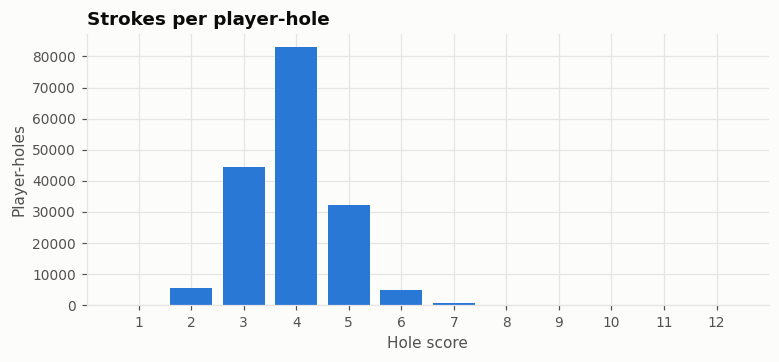

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.2))
vc = hole.hole_score.value_counts().sort_index()
ax.bar(vc.index, vc.values, color=PALETTE[0], width=0.8)
ax.set(title="Strokes per player-hole", xlabel="Hole score", ylabel="Player-holes")
ax.set_xticks(vc.index)
plt.show()

## Step 3 · Decode the lie codes

Every hole starts on the tee and ends in the cup. Putts happen on the green. A penalty follows trouble. We need to measure how each code behaves against those rules.

In [8]:
nxt_pen = df.groupby(HOLE_KEY, sort=False).is_penalty.shift(-1, fill_value=False)
df["_next_is_penalty"] = nxt_pen

before = df[df.lie_before.notna()].groupby("lie_before").agg(
    strokes_from=("shot_no", "size"),
    first_shot_share=("shot_no", lambda s: (s == 1).mean()),
    median_yd_before=("yd_before", "median"),
    holed_share=("lie_after", lambda s: (s == "LIE_9").mean()),
    top_club=("club", lambda s: s.value_counts().index[0] if s.notna().any() else "-"),
)
after = df.groupby("lie_after").agg(
    landed_in=("shot_no", "size"),
    penalty_next_share=("_next_is_penalty", "mean"),
)
lie_table = before.join(after, how="outer")
lie_table["inferred_lie"] = lie_table.index.map(LIE_LABEL)
lie_table["group"] = lie_table.index.map(LIE_GROUP)
lie_table.sort_values("landed_in", ascending=False).round(3)

,strokes_from,first_shot_share,median_yd_before,holed_share,top_club,landed_in,penalty_next_share,inferred_lie,group
lie_before,,,,,,,,,
LIE_6,273199.0,0.000,1.707,0.611,Putter,273200,0.000,Green,green
LIE_9,NaN,NaN,NaN,NaN,NaN,170694,0.000,Holed,holed
LIE_4,102506.0,0.000,140.589,0.006,Iron,102356,0.000,Fairway,fairway
LIE_15,55462.0,0.000,113.987,0.006,Wedge,55315,0.002,Rough,rough
LIE_10,20061.0,0.000,73.709,0.019,Wedge,20064,0.000,Rough (light / first cut),rough
LIE_8,12590.0,0.000,18.313,0.009,Wedge,12599,0.001,Rough (around green),rough
LIE_11,9151.0,0.000,154.150,0.001,Wedge,9410,0.030,Bunker,sand
LIE_7,7230.0,0.000,8.215,0.106,Putter,7180,0.000,Fringe,fringe
LIE_5,6479.0,0.000,169.116,0.000,Wedge,6489,0.001,Fairway bunker,sand


LIE_16 is the tee (98.6% of its strokes are first strokes). LIE_6 is the green (putter, about 2 yards out). LIE_4 is the fairway, LIE_15 the rough and LIE_11 a bunker. LIE_19, 18 and 14 are almost always followed by a penalty. Next: tell those three apart.

Water and out of bounds are handled differently. After water, the ball is dropped near where it went in， that's how the water is told. After out of bounds, the ball goes back to where the last shot was hit.

In [9]:
g = df.groupby(HOLE_KEY, sort=False)
nxt = pd.DataFrame({
    "pen": g.is_penalty.shift(-1, fill_value=False),
    "placed_lie": g.lie_after.shift(-1),
    "placed_yd": g.yd_after.shift(-1),
})
land = df.join(nxt)
rows = []
for code in ["LIE_19", "LIE_18", "LIE_14", "LIE_1"]:
    x = land[land.lie_after == code]
    p = x[x.pen]
    rows.append({
        "lie": code,
        "landings": len(x),
        "penalty_next": x.pen.mean(),
        "median_yd_from_hole": x.yd_after.median(),
        "placed_back_on_tee": (p.placed_lie == "LIE_16").mean(),
        "yd_moved_back_from_landing": (p.placed_yd - p.yd_after).median(),
        "yd_from_previous_shot_spot": (p.placed_yd - p.yd_before).median(),
    })
pd.DataFrame(rows).set_index("lie").round(2)

,landings,penalty_next,median_yd_from_hole,placed_back_on_tee,yd_moved_back_from_landing,yd_from_previous_shot_spot
lie,,,,,,
LIE_19,3017,0.97,33.09,0.06,32.03,-154.13
LIE_18,250,0.99,184.37,0.85,259.12,-10.52
LIE_14,178,0.93,143.33,0.72,244.77,-0.28
LIE_1,641,0.47,160.11,0.08,2.22,-260.23


LIE_19 is water: the drop is about 30 yards behind the landing spot. LIE_18 and LIE_14 are out of bounds or lost balls, because most go back to the tee. LIE_1 draws a penalty only half the time, so it looks like trees where players sometimes declare an unplayable lie. Next: confirm the ordering by difficulty.

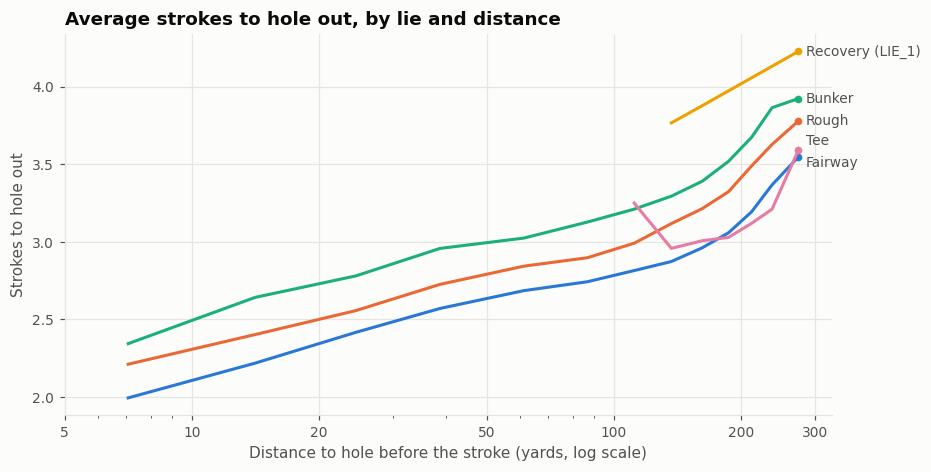

In [10]:
clean = df[df.lie_before.notna() & (df.hole_rows == df.hole_score)]
bins = np.array([5, 10, 20, 30, 50, 75, 100, 125, 150, 175, 200, 225, 250, 300])
clean = clean.assign(dbin=pd.cut(clean.yd_before, bins))
mid = {iv: (iv.left * iv.right) ** 0.5 for iv in clean.dbin.cat.categories}

show = [("LIE_4", "Fairway"), ("LIE_15", "Rough"), ("LIE_11", "Bunker"),
        ("LIE_1", "Recovery (LIE_1)"), ("LIE_16", "Tee")]
fig, ax = plt.subplots(figsize=(9, 4.5))
for (code, name), col in zip(show, PALETTE):
    s = clean[clean.lie_before == code].groupby("dbin", observed=True).strokes_remaining.agg(["mean", "size"])
    s = s[s["size"] >= 30]
    x = [mid[i] for i in s.index]
    ax.plot(x, s["mean"], color=col)
    nudge = {"Tee": 0.06, "Fairway": -0.04}.get(name, 0)
    ax.plot([x[-1]], [s["mean"].iloc[-1]], "o", ms=4, color=col)
    ax.annotate(name, xy=(x[-1], s["mean"].iloc[-1] + nudge), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK_2)
ax.set_xscale("log")
ax.set_xticks([5, 10, 20, 50, 100, 200, 300])
ax.set_xticklabels(["5", "10", "20", "50", "100", "200", "300"])
ax.set(title="Average strokes to hole out, by lie and distance",
       xlabel="Distance to hole before the stroke (yards, log scale)", ylabel="Strokes to hole out")
plt.show()

At every distance, fairway is easier than rough, rough is easier than a bunker, and trouble is hardest. The decoding holds. The putting curve below is a last sanity check.

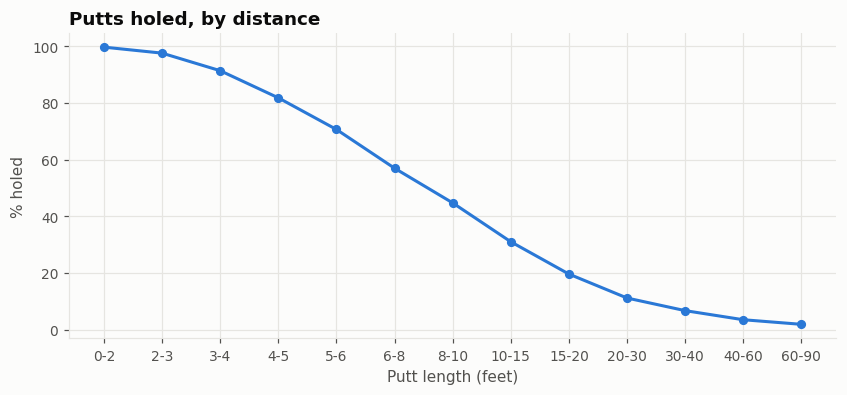

ft,"(0, 2]","(2, 3]","(3, 4]","(4, 5]","(5, 6]","(6, 8]","(8, 10]","(10, 15]","(15, 20]","(20, 30]","(30, 40]","(40, 60]","(60, 90]"
one_putt,0.997,0.976,0.914,0.818,0.706,0.570,0.447,0.310,0.196,0.111,0.067,0.035,0.019
exp_strokes,1.003,1.024,1.087,1.183,1.296,1.433,1.557,1.697,1.816,1.914,1.993,2.098,2.252
n,75746.000,27822.000,18808.000,12901.000,9759.000,15886.000,12083.000,23090.000,17123.000,25919.000,16303.000,13978.000,3493.000


In [11]:
putts = clean[clean.lie_before == "LIE_6"].assign(ft=lambda d: d.yd_before * 3)
pb = pd.cut(putts.ft, [0, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 60, 90])
pt = putts.groupby(pb, observed=True).agg(
    one_putt=("lie_after", lambda s: (s == "LIE_9").mean()),
    exp_strokes=("strokes_remaining", "mean"),
    n=("shot_no", "size"),
)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot([f"{int(i.left)}-{int(i.right)}" for i in pt.index], pt.one_putt * 100, color=PALETTE[0], marker="o", ms=5)
ax.set(title="Putts holed, by distance", xlabel="Putt length (feet)", ylabel="% holed")
plt.show()
pt.round(3).T

Putts inside 3 feet almost always drop, 8-footers about half the time. The data behaves like real golf. Next: data quality.

## Step 4 · Check data quality

In [12]:
df = flag_quality(df)
hole = df.drop_duplicates(HOLE_KEY)

so = hole[hole.score_only_hole]
print(f"Score-only holes: {len(so):,} ({len(so)/len(hole):.1%} of player-holes)")
print("Their recorded scores:", so.hole_score.value_counts().sort_index().to_dict())
aces = hole[(hole.hole_rows == 1) & (hole.hole_score == 1)]
print(f"Genuine holes in one (1 row, score 1): {len(aces)}")

by_ev = hole.groupby("event_id").score_only_hole.mean().sort_values(ascending=False)
by_ev.head(6).round(3)

Score-only holes: 1,640 (1.0% of player-holes)
Their recorded scores: {2: 55, 3: 430, 4: 891, 5: 228, 6: 31, 7: 5}
Genuine holes in one (1 row, score 1): 16


event_id
9642420ac8    0.318
a847824483    0.288
b48f0ae7ea    0.219
3b360c3fe5    0.001
1b3dd63850    0.000
0839275271    0.000
Name: score_only_hole, dtype: float64

About 1% of holes have a final score but no shots, mostly in three events. The scores look normal, and the 16 one-shot holes match the real hole-in-one rate, so these are real scores with the detail missing. We keep them for total scoring only. Next: events with rougher data.

In [13]:
ev = df.groupby("event_id").agg(
    start=("event_start_date", "first"),
    courses=("course_no", "nunique"),
    players=("player_id", "nunique"),
    distance_missing=("distance", lambda s: s.isna().mean()),
    low_quality=("low_quality_event", "first"),
).join(by_ev.rename("score_only_share"))
ev.sort_values("start").query("low_quality or courses > 1").round({"distance_missing": 3, "score_only_share": 3})

,start,courses,players,distance_missing,low_quality,score_only_share
event_id,,,,,,
a847824483,2022-08-11,2,20,0.105,True,0.288
0a95ba2255,2022-09-29,3,78,0.794,True,0.000
9642420ac8,2023-08-17,2,29,0.115,True,0.318
b48f0ae7ea,2023-10-05,3,71,0.835,True,0.219


In [14]:
lq = df[df.low_quality_event & df.lie_before.eq("LIE_6")]
hq = df[~df.low_quality_event & df.lie_before.eq("LIE_6")]
print("Share of putt distances that are whole feet (multiple of 12 in):")
print(f"  low-quality events : {(lq.distance_before_inch % 12 == 0).mean():.0%}")
print(f"  other events       : {(hq.distance_before_inch % 12 == 0).mean():.0%}")

Share of putt distances that are whole feet (multiple of 12 in):
  low-quality events : 43%
  other events       : 0%


Four multi-course events have distances rounded to whole feet and some wrong tee yardages. We flag them rather than drop them, and test later whether they change anything.

In [15]:
t = df[(df.shot_no == 1) & ~df.low_quality_event & df.distance.notna() & df.lie_before.eq("LIE_16")]
ratio = t.distance / (t.distance_before_inch - t.distance_after_inch)
print("distance / (before − after) for tee shots: median {:.3f}, IQR {:.3f} to {:.3f}".format(
    ratio.median(), ratio.quantile(.25), ratio.quantile(.75)))
gaps = hole[(hole.hole_rows > 1) & (hole.hole_rows < hole.hole_score)]
print("Multi-row holes missing a stroke row:", len(gaps))

prev_lie = df.groupby(HOLE_KEY, sort=False).lie_after.shift()
prev_dist = df.groupby(HOLE_KEY, sort=False).distance_after_inch.shift()
m = df.lie_before.notna() & prev_lie.notna() & ~df.is_penalty
print(f"lie_before equals previous lie_after: {(df.lie_before[m] == prev_lie[m]).mean():.2%}")
print(f"distance_before equals previous distance_after (±1 in): {((df.distance_before_inch[m] - prev_dist[m]).abs() < 1).mean():.2%}")

brk = df[m & (df.lie_before != prev_lie)]
pd.crosstab(prev_lie[brk.index], brk.lie_before).stack().sort_values(ascending=False).head(5).rename("strokes")

distance / (before − after) for tee shots: median 1.007, IQR 0.972 to 1.039
Multi-row holes missing a stroke row: 2


lie_before equals previous lie_after: 99.85%
distance_before equals previous distance_after (±1 in): 99.60%


lie_after  lie_before
LIE_12     LIE_15        229
           LIE_4         119
           LIE_11         51
LIE_10     LIE_4          42
LIE_11     LIE_15         34
Name: strokes, dtype: int64

The recorded `distance` matches before minus after, and 99.8% of strokes start where the previous one ended. The sequences are reliable. The exceptions after LIE_12 carry no penalty, which suggests free relief such as a cart path. Next: par.

## Step 5 · Infer par

If tee shots usually finish within 60 yards of the hole, players were aiming at the green, so the hole is a par 3. Between 60 and 205 yards it is a par 4, and beyond that a par 5. The field's scoring average breaks close calls.

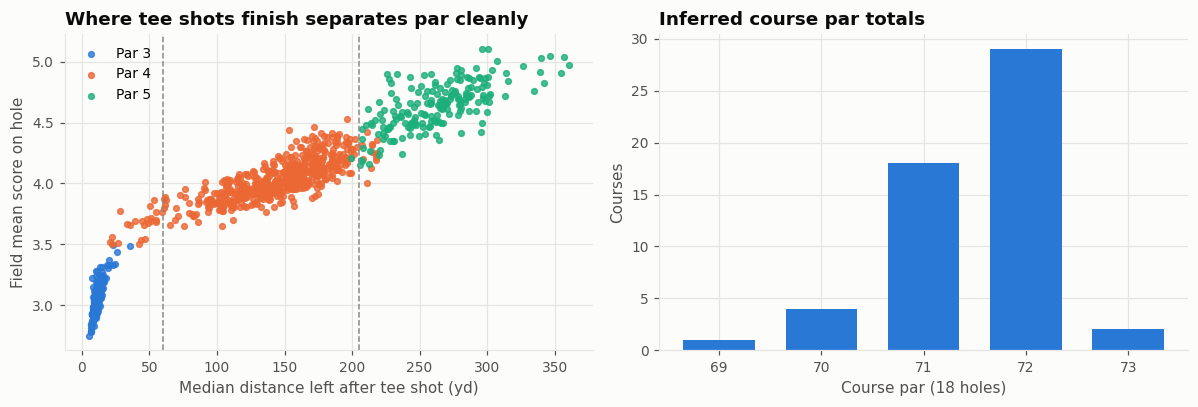

{'tee_shot_finish': 936, 'field_mean_score': 36}


,holes,median_yd,mean_score
par,,,
3,218,190.5,3.05
4,563,433.0,4.03
5,191,568.0,4.64


In [16]:
ch = infer_par(df)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
for p, col in zip([3, 4, 5], PALETTE):
    d = ch[ch.par == p]
    ax.scatter(d.tee_after_med_yd, d.mean_score, s=14, color=col, alpha=.8, label=f"Par {p}")
ax.axvline(60, color=NEUTRAL, lw=1, ls="--"); ax.axvline(205, color=NEUTRAL, lw=1, ls="--")
ax.set(title="Where tee shots finish separates par cleanly", xlabel="Median distance left after tee shot (yd)",
       ylabel="Field mean score on hole")
ax.legend(loc="upper left")

ax = axes[1]
tot = ch.groupby(["event_id", "course_no"]).par.sum().value_counts().sort_index()
ax.bar(tot.index.astype(str), tot.values, color=PALETTE[0], width=0.7)
ax.set(title="Inferred course par totals", xlabel="Course par (18 holes)", ylabel="Courses")
plt.tight_layout(); plt.show()

print(ch.par_source.value_counts().to_dict())
ch.groupby("par").agg(holes=("par", "size"), median_yd=("hole_yd", "median"),
                      mean_score=("mean_score", "mean")).round(2)

The three groups separate cleanly, and 53 of 54 courses add up to par 70 to 73. Next: label every shot.

## Step 6 · Label every shot

A drive is a tee shot on a par 4 or 5. A putt is any stroke from the green. Everything else is an approach if it is over 100 yards, and a short-game shot if not. A penalty counts against the shot that caused it.

In [17]:
df = add_par_and_category(df, ch)
detail = df[~df.score_only_hole]
area = detail.groupby("category").agg(strokes=("shot_no", "size"), median_yd=("yd_before", "median"),
                                      penalties=("is_penalty", "sum"))
area["share"] = area.strokes / area.strokes.sum()
area.round(3)

,strokes,median_yd,penalties,share
category,,,,
APP,168527,177.490,2086,0.253
ARG,90567,21.116,171,0.136
OTT,133267,453.000,2151,0.200
PUTT,273198,1.707,1,0.410


Putting is about 41% of all strokes, which is normal. Next: two facts that shape the models.

## Two facts for the next notebook

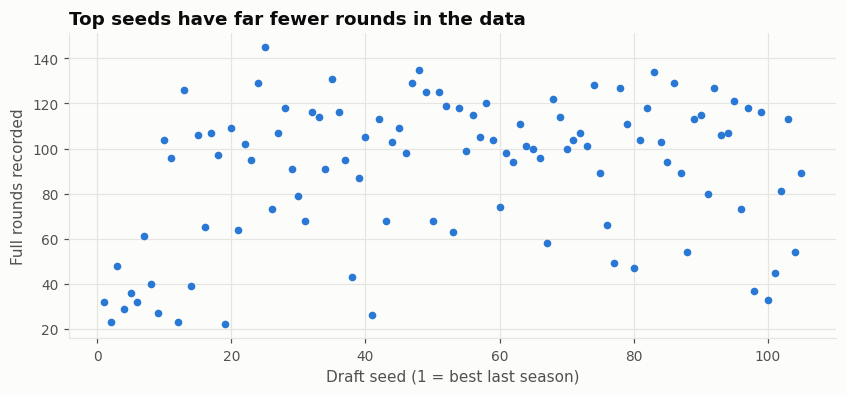

,rounds,events
tier,,
"(0, 10]",34.0,10.0
"(10, 20]",96.5,30.0
"(20, 30]",98.5,31.5
"(30, 40]",100.0,31.5
"(40, 50]",106.0,34.5
"(50, 105]",104.0,33.0


In [18]:
full_rounds = (df.drop_duplicates(HOLE_KEY).groupby(ROUND_KEY).agg(score=("hole_score", "sum"), holes=("hole_no", "size"))
               .query("holes == 18").reset_index())
pl = full_rounds.groupby("player_id").agg(rounds=("score", "size"), events=("event_id", "nunique"))
pl = pl.join(df.groupby("player_id").draft_seed.first())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.scatter(pl.draft_seed, pl.rounds, s=16, color=PALETTE[0])
ax.set(title="Top seeds have far fewer rounds in the data", xlabel="Draft seed (1 = best last season)",
       ylabel="Full rounds recorded")
plt.show()
pl.assign(tier=pd.cut(pl.draft_seed, [0, 10, 20, 30, 40, 50, 105])).groupby("tier", observed=True)[["rounds", "events"]].median()

Top-10 seeds have about a third as many rounds as everyone else. Their ratings will need extra caution.

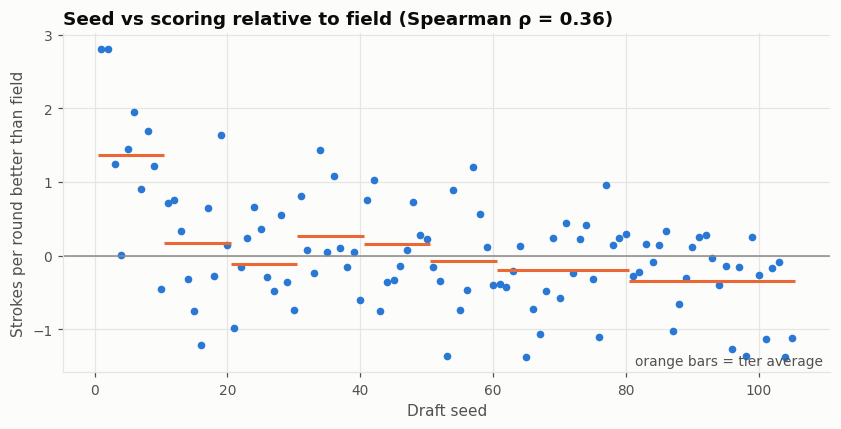

draft_seed
(0, 10]      1.36
(10, 20]     0.17
(20, 30]    -0.12
(30, 40]     0.26
(40, 50]     0.15
(50, 60]    -0.07
(60, 80]    -0.19
(80, 105]   -0.34
Name: strokes_better_than_field, dtype: float64

In [19]:
full_rounds["rel"] = full_rounds.score - full_rounds.groupby(["event_id", "round_no", "course_no"]).score.transform("mean")
rel = full_rounds.groupby("player_id").rel.mean().rename("rel_to_field")
pl = pl.join(rel)
rho, pval = spearmanr(pl.draft_seed, pl.rel_to_field)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(pl.draft_seed, -pl.rel_to_field, s=16, color=PALETTE[0])
tier = pd.cut(pl.draft_seed, [0, 10, 20, 30, 40, 50, 60, 80, 105])
tm = pl.groupby(tier, observed=True).rel_to_field.mean()
for iv, v in tm.items():
    ax.hlines(-v, iv.left + 0.5, iv.right + 0.5, color=PALETTE[1], lw=2)
ax.axhline(0, color=NEUTRAL, lw=1)
ax.set(title=f"Seed vs scoring relative to field (Spearman ρ = {rho:.2f})",
       xlabel="Draft seed", ylabel="Strokes per round better than field")
ax.text(0.99, 0.02, "orange bars = tier average", transform=ax.transAxes, ha="right", fontsize=9, color=INK_2)
plt.show()
(-tm).round(2).rename("strokes_better_than_field")

Last season's seed only loosely predicts scoring (ρ ≈ 0.36), and seeds 11 to 50 look almost the same. If our ratings can see more than the seed does, the draft has room to find value. Notebook 02 builds those ratings.